In [176]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML
from econml.dr import DRLearner
import matplotlib.pyplot as plt
from dowhy import CausalModel, gcm
import graphviz
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler


In [177]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["lib_category"] = df["code_location"].apply(
    lambda x: x if x != "developer_written" else "source"
)

print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())



Original rows: 6140
After removing obfuscated: 5612

Verdict value counts:
verdict
0    2898
1    2714
Name: count, dtype: int64

Code location value counts:
code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64


In [178]:
scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])
print(df["apk_size_scaled"].describe())

count    5612.000000
mean        0.489310
std         1.437216
min        -0.719854
25%        -0.336389
50%         0.000000
75%         0.663611
max         9.086488
Name: apk_size_scaled, dtype: float64


In [179]:
category_order = [
    '<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
    '50k-100k','100k-500k','500k-1M','1M-5M','>5M'
]
ord_map = {c: i for i, c in enumerate(category_order)}

df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)

df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

print("\nApp popularity encoded value counts:")
print(df["app_popularity_encoded"].value_counts().sort_index())


App popularity encoded value counts:
app_popularity_encoded
0     626
1     604
2     317
3     323
4     415
5     449
6     413
7     704
8     602
9     641
10    518
Name: count, dtype: int64


In [180]:
small_libs = ["SocialMedia", "Analytics", "Cloud"]
df["lib_grouped"] = df["code_location"].replace(small_libs, "Small_Libraries")
df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"  

df["lib_grouped"].value_counts()


lib_grouped
Utilities          3039
others             1341
App_Source_Code     511
Android             494
Small_Libraries     227
Name: count, dtype: int64

In [181]:
df.head()


,alert_description,verdict,artifact_location,app_package_name,version_code,app_popularity,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category,apk_size_scaled,app_popularity_encoded,lib_grouped
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,others,0.015672,0,others
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,others,0.015672,0,others
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,Android,0.015672,0,Android
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,Android,0.015672,0,Android
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,1,Android,-0.674171,4,Android


In [182]:
libs = list(df["lib_grouped"].unique())

libs = ["App_Source_Code"] + [l for l in libs if l != "App_Source_Code"]

lib_cat = pd.Categorical(df["lib_grouped"], categories=libs, ordered=True)
df["lib_treat_code"] = lib_cat.codes   

print("Treatment levels (code -> label):")
for k, name in enumerate(libs):
    print(f"{k}: {name}")
print()

Y = df["verdict"].values           
T = df["lib_treat_code"].values     

feature_cols = ["app_popularity_encoded"]
X = df[feature_cols].values
W = X.copy()

mask = ~np.isnan(X).any(axis=1)
Y = Y[mask]
T = T[mask]
X = X[mask]
W = W[mask]

Treatment levels (code -> label):
0: App_Source_Code
1: others
2: Android
3: Utilities
4: Small_Libraries



In [183]:
dr = DRLearner(model_regression=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    ),
    model_final=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42
    ),
    categories='auto',   
    # random_state=42
)

dr.fit(Y, T, X=X, W=W)

print("Fitted DRLearner with discrete multi-valued treatment.\n")

Fitted DRLearner with discrete multi-valued treatment.



In [184]:
results = []

n = len(Y)
baseline_code = 0  

for k, lib_name in enumerate(libs):
    if k == baseline_code:
        continue  

    T0 = np.full(n, baseline_code, dtype=int)
    T1 = np.full(n, k, dtype=int)

    tau = dr.effect(X=X, T0=T0, T1=T1)
    tau_mean = float(np.mean(tau))
    tau_std = float(np.std(tau))

    results.append({
        "library": lib_name,
        "ATE_vs_App_Source_Code": tau_mean,
        "ATE_std": tau_std,
        "n_samples": n
    })

results_df = pd.DataFrame(results).sort_values("ATE_vs_App_Source_Code")
print("Estimated causal effect of each library type vs App_Source_Code:")
print(results_df, "\n")


Estimated causal effect of each library type vs App_Source_Code:
           library  ATE_vs_App_Source_Code   ATE_std  n_samples
2        Utilities               -0.372075  0.170962       5612
0           others               -0.072935  0.163220       5612
1          Android                0.106757  0.137339       5612
3  Small_Libraries                0.283226  0.195468       5612 



In [185]:
def bootstrap_df(df, n_boot=50):
    boot_samples = []
    for i in range(n_boot):
        sample = df.sample(frac=1, replace=True)
        boot_samples.append(sample)
    return boot_samples

In [186]:
effects = []

for lib in ["Utilities", "Android", "Small_Libraries", "others"]:
    for bdf in bootstrap_df(df, n_boot=10):
        Y = bdf["verdict"].values
        X = bdf[["apk_size_scaled", "app_popularity_encoded"]].values
        T = (bdf["lib_grouped"] == lib).astype(int).values  

        dr = DRLearner(
            model_regression=RandomForestRegressor(n_estimators=200),
            model_propensity=RandomForestClassifier(n_estimators=200),
            model_final=RandomForestRegressor(n_estimators=200),
            random_state=None  
        )
        dr.fit(Y, T, X=X)
        
        tau = dr.effect(X)
        effects.append(np.mean(tau))

    print("Bootstrap mean:", np.mean(effects))
    print("Bootstrap std:", np.std(effects))
    print("95% CI:", np.percentile(effects, [2.5, 97.5]))


Bootstrap mean: -700.9288247400453
Bootstrap std: 726.1809509188862
95% CI: [-1967.89389817   196.89257747]
Bootstrap mean: -128.8548130278652
Bootstrap std: 835.469932716747
95% CI: [-1875.91224119  1025.11350383]
Bootstrap mean: -124.04809980094339
Bootstrap std: 699.9646932449944
95% CI: [-1783.93058421   970.2459579 ]
Bootstrap mean: 8.890834265699741
Bootstrap std: 708.0152287474783
95% CI: [-1691.94892723  1140.49656362]


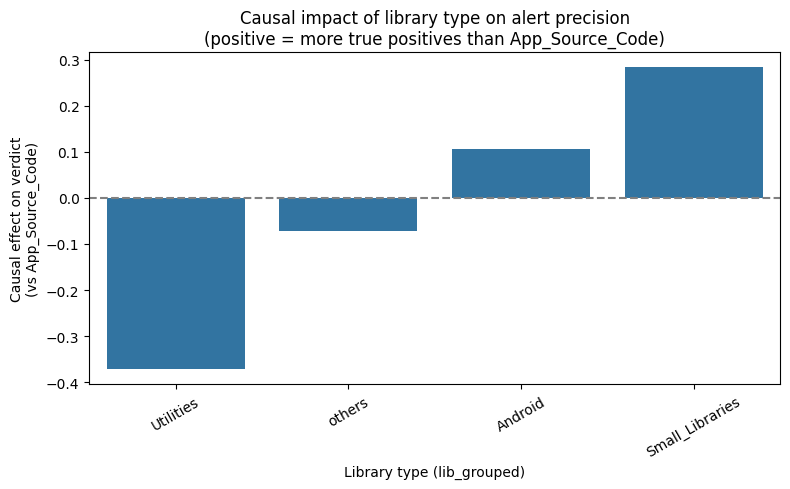

Library 'Utilities' reduces precision relative to App_Source_Code: -0.372 (std 0.171)
Library 'others' reduces precision relative to App_Source_Code: -0.073 (std 0.163)
Library 'Android' improves precision relative to App_Source_Code: 0.107 (std 0.137)
Library 'Small_Libraries' improves precision relative to App_Source_Code: 0.283 (std 0.195)


In [187]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="library",
    y="ATE_vs_App_Source_Code",
    data=results_df,
    capsize=0.2
)
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Causal effect on verdict\n(vs App_Source_Code)")
plt.xlabel("Library type (lib_grouped)")
plt.title("Causal impact of library type on alert precision\n(positive = more true positives than App_Source_Code)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

for _, row in results_df.iterrows():
    direction = "reduces" if row["ATE_vs_App_Source_Code"] < 0 else "improves"
    print(
        f"Library '{row['library']}' {direction} precision relative to App_Source_Code: "
        f"{row['ATE_vs_App_Source_Code']:.3f} (std {row['ATE_std']:.3f})"
    )
